In [1]:
library(Signac)
library(Seurat)
library(ggplot2)
library(dplyr)
library(BuenColors)
library(GenomeInfoDb)
library(jsonlite)
library(EnsDb.Mmusculus.v79)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: MASS


Attaching package: ‘MASS’


The following object is masked from ‘package:dplyr’:

    select


Loading required package: BiocGenerics

Warning message:
“package ‘BiocGenerics’ was built under R version 4.3.2”

Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following object is masked from ‘package:SeuratObject’:

    intersect


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aper

#### Figure 1h: H3K27ac integration with scCUT&Tag to infer cell types in SPACE-Tag data

In [2]:
annotations <- GetGRangesFromEnsDb(ensdb = EnsDb.Mmusculus.v79)
seqlevelsStyle(annotations) <- 'UCSC'
annotations <- keepStandardChromosomes(annotations, pruning.mode="coarse")
genome(annotations) <- "mm10"

Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warn

##### Load and preprocess reference scCUT\&Tag data

In [3]:
sccutntag_ref <- readRDS('./processed_data/public-data/GSE198467_H3K27ac_Seurat_object_clustered_renamed.Rds')
sccutntag_ref <- UpdateSeuratObject(object = sccutntag_ref)

Validating object structure

Updating object slots

Ensuring keys are in the proper structure

Updating matrix keys for DimReduc 'lsi'

Updating matrix keys for DimReduc 'umap'

Ensuring keys are in the proper structure

Ensuring feature names don't have underscores or pipes

Updating slots in peaks

Updating slots in GA

Updating slots in peaks_nn

Setting default assay of peaks_nn to peaks

Updating slots in peaks_snn

Setting default assay of peaks_snn to peaks

Updating slots in lsi

Updating slots in umap

Setting umap DimReduc to global

Setting assay used for RunUMAP.peaks.lsi to peaks

Setting assay used for FindNeighbors.peaks.lsi to peaks

No assay information could be found for FindClusters

Warning message:
"Adding a command log without an assay associated with it"
Validating object structure for ChromatinAssay 'peaks'

Validating object structure for Assay 'GA'

Validating object structure for Graph 'peaks_nn'

Validating object structure for Graph 'peaks_snn'

Validating 

In [4]:
sccutntag_ref@assays$peaks <- as.ChromatinAssay(sccutntag_ref@assays$peaks)

In [5]:
ref_frags <- CreateFragmentObject(path = './processed_data/public-data/GSE198467_H3K27ac_fragments.tsv.gz', cells = WhichCells(sccutntag_ref))

Computing hash



In [6]:
Fragments(sccutntag_ref) <- NULL
Fragments(sccutntag_ref) <- ref_frags

##### Load and preprocess SPACE-Tag H3K72ac data

In [7]:
# Requantify SPACE-Tag data with reference peaks

ref_peaks <- StringToGRanges(rownames(sccutntag_ref), sep=c('-','-'))

In [8]:
space_tag_h3k27ac <- readRDS('./processed_data/space-tag/p28_brain_h3k27ac_merged_registered.rds')

In [9]:
counts <- FeatureMatrix(Fragments(space_tag_h3k27ac), ref_peaks)
chrom_assay <- CreateChromatinAssay(
  counts = counts,
  sep = c(":", "-"),
  fragments = Fragments(space_tag_h3k27ac),
  min.cells = 1,
  min.features = 1
)
space_tag_h3k27ac@assays$peaks <- chrom_assay

Extracting reads overlapping genomic regions

Extracting reads overlapping genomic regions



Extracting reads overlapping genomic regions

Extracting reads overlapping genomic regions



##### Perform Anchor-based integration

In [10]:
DefaultAssay(space_tag_h3k27ac) <- 'peaks'
DefaultAssay(sccutntag_ref) <- 'peaks'

In [11]:
# filter for common features in both datasets
common_features <- intersect(rownames(sccutntag_ref), rownames(space_tag_h3k27ac))
sccutntag_ref <- subset(sccutntag_ref, features = common_features)
space_tag_h3k27ac <- subset(space_tag_h3k27ac, features = common_features)

Warning message:
"Adding image data that isn't associated with any assays"
Warning message:
"Not validating Seurat objects"
Warning message:
"Adding image data that isn't associated with any assays"
Warning message:
"Not validating Seurat objects"
Warning message:
"Adding image data that isn't associated with any assays"
Warning message:
"Not validating Seurat objects"
Warning message:
"Adding image data that isn't associated with any assays"
Warning message:
"Not validating Seurat objects"


In [12]:
sccutntag_ref <- RunTFIDF(sccutntag_ref)
sccutntag_ref <- FindTopFeatures(sccutntag_ref, min.cutoff = 'q0')
sccutntag_ref <- RunSVD(sccutntag_ref)

Performing TF-IDF normalization

Warning message in RunTFIDF.default(object = GetAssayData(object = object, slot = "counts"), :
"Some features contain 0 total counts"
Running SVD

Scaling cell embeddings



In [13]:
space_tag_h3k27ac <- RunTFIDF(space_tag_h3k27ac)
space_tag_h3k27ac <- FindTopFeatures(space_tag_h3k27ac, min.cutoff = 'q0')
space_tag_h3k27ac <- RunSVD(space_tag_h3k27ac)

Performing TF-IDF normalization

Running SVD



Scaling cell embeddings



In [14]:
# find transfer anchors
transfer.anchors <- FindTransferAnchors(
  reference = sccutntag_ref,
  query = space_tag_h3k27ac,
  reference.reduction = "lsi",
  reduction = "lsiproject",
  dims = 2:30
)

Projecting new data onto SVD

Warning message:
"Adding image data that isn't associated with any assays"
Warning message:
"Adding image data that isn't associated with any assays"
Warning message:
"Adding image data that isn't associated with any assays"
Warning message:
"Adding image data that isn't associated with any assays"
Finding neighborhoods

Finding anchors

	Found 1557 anchors



In [15]:
predictions <- TransferData(anchorset = transfer.anchors, refdata = sccutntag_ref@meta.data$idents_short, weight.reduction = 'lsiproject')

Finding integration vectors

Finding integration vector weights

Predicting cell labels



In [16]:
space_tag_h3k27ac <- AddMetaData(space_tag_h3k27ac, metadata = predictions)

##### Generate plots

In [17]:
# Plot mature oligodendrocytes, telecephalic astrocytes, non-telencephalic astrocytes, and inhibitory neurons
plot_cell_types <- c('MOL', 'AST_TE', 'AST_NT', 'INH3')

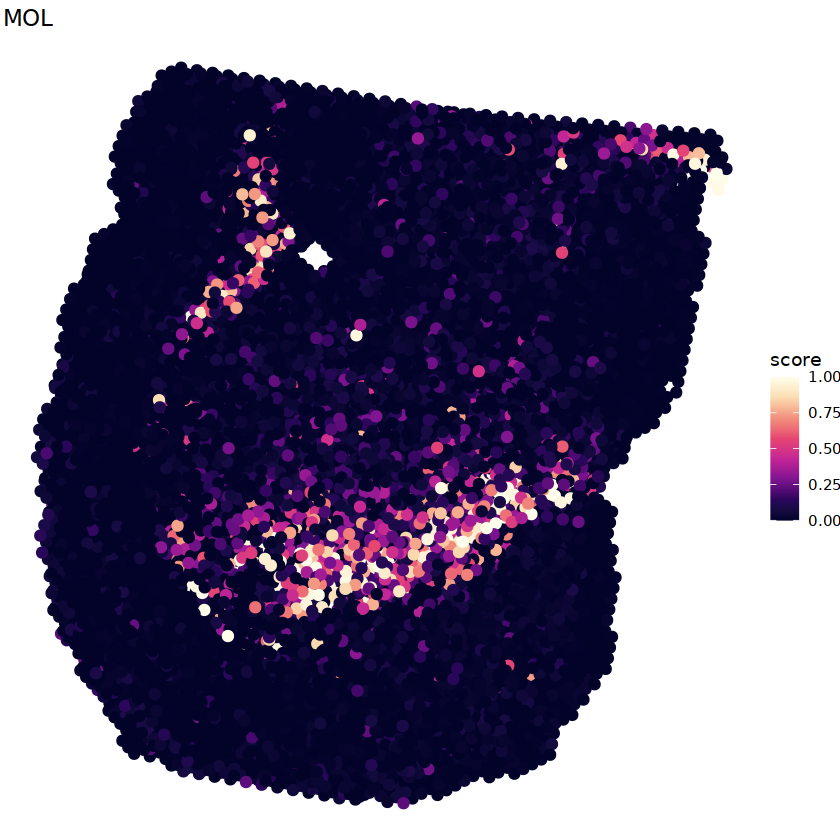

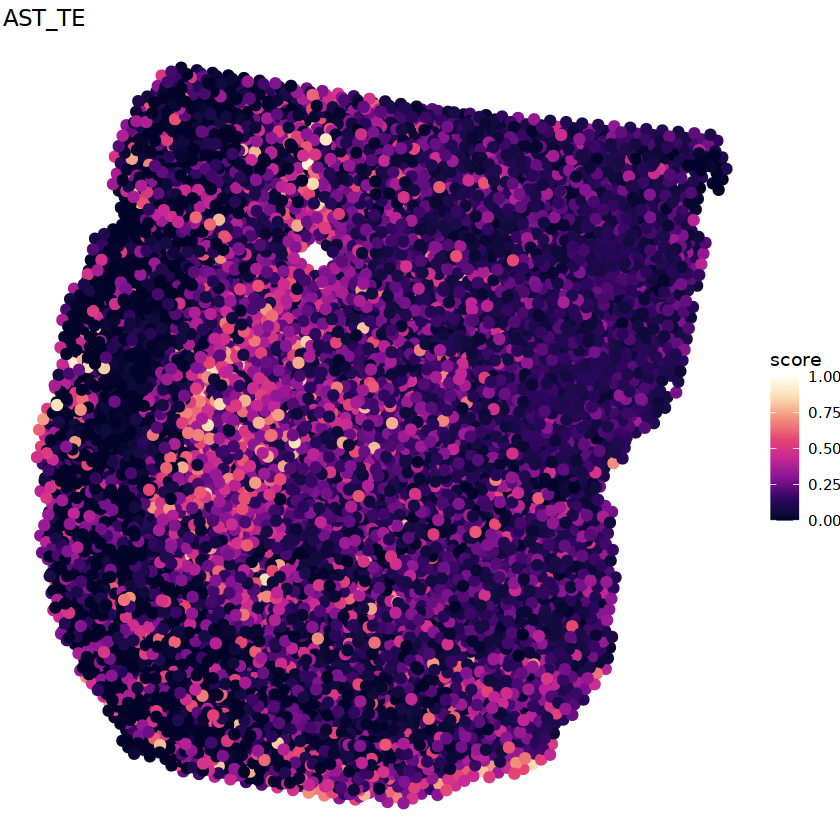

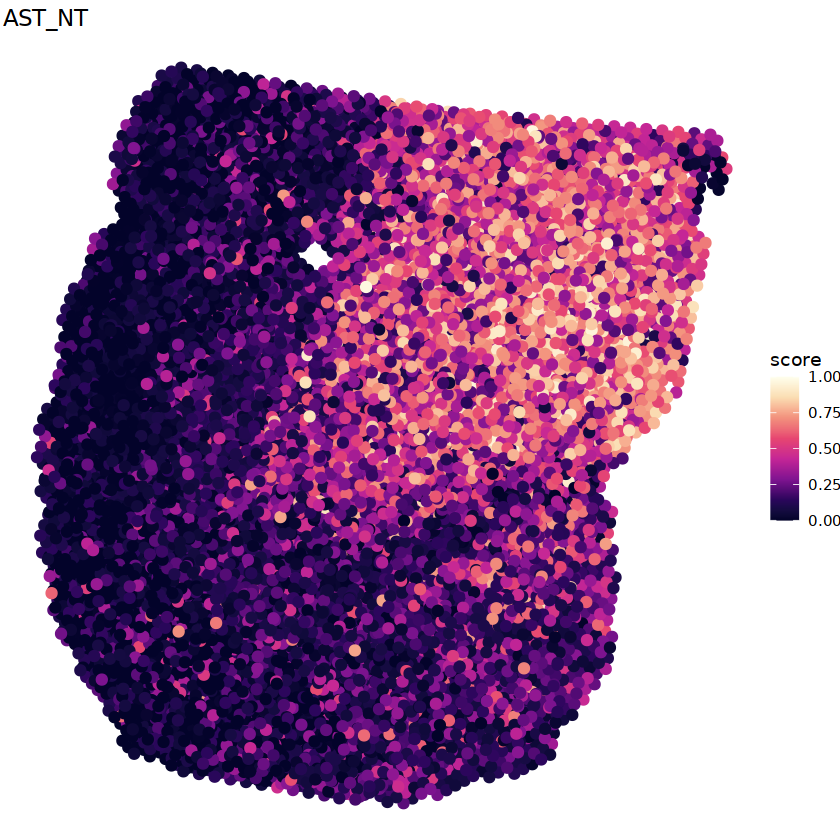

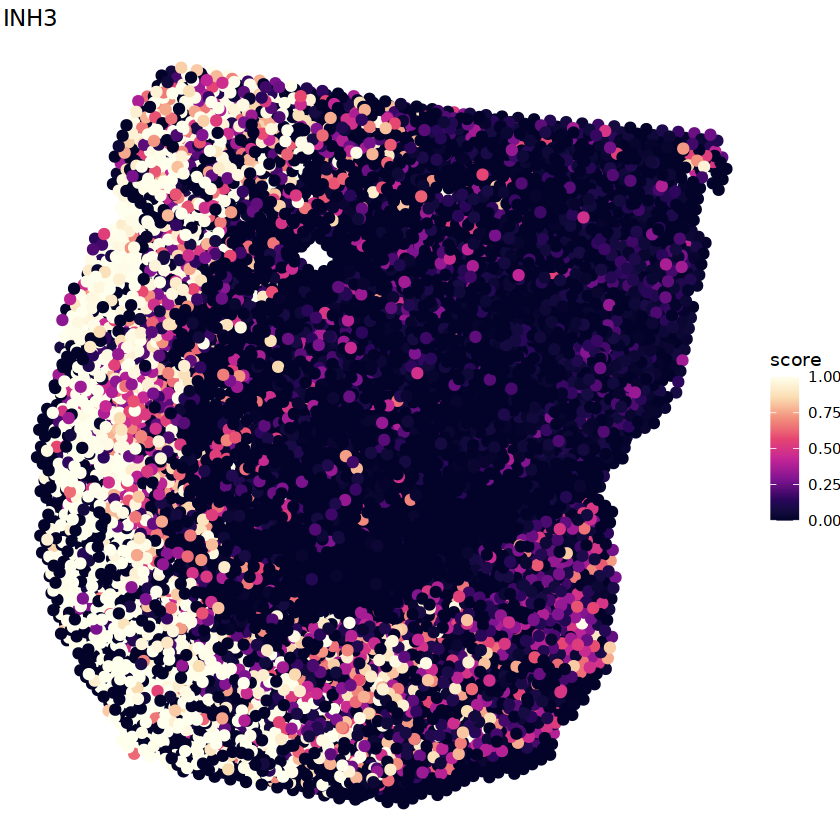

In [18]:
# implement custom plotting with randomization 
for (cell_type in plot_cell_types) {
  plot_df <- data.frame(score = space_tag_h3k27ac@meta.data[[paste0('prediction.score.', cell_type)]], coord_row = space_tag_h3k27ac@images$image@coordinates$x, coord_col = space_tag_h3k27ac@images$image@coordinates$y)

  shuffled_df <- plot_df %>%
        sample_n(size = nrow(plot_df), replace = FALSE)

  p <- ggplot(shuffled_df) + geom_point(aes(x=1.5*coord_col, y=coord_row, color=score), size=2.4, alpha = 1) +  
       scale_color_gradientn(colors=jdb_palette('china_dragon'), limits=c(0, 1), oob = scales::squish) + 
       theme_void() + theme(legend.position = "right") + coord_equal() + scale_y_reverse() + ggtitle(cell_type)
  print(p)
}

##### Environment

In [20]:
sessionInfo()

R version 4.3.1 (2023-06-16)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 22.04.4 LTS

Matrix products: default
BLAS/LAPACK: /gpfs/commons/home/rhe/.conda/envs/sc_analysis/lib/libopenblasp-r0.3.24.so;  LAPACK version 3.11.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: America/New_York
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] future_1.67.0              EnsDb.Mmusculus.v79_2.99.0
 [3] ensembldb_2.24.1           AnnotationFilter_1.24.0   
 [5] GenomicFeatures_1.52.2     AnnotationDbi_1.64.1      
 [7] Biobase_2.62.0